In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv('cleaned_dataaa.csv')
df

,Дата вылета,Время вылета,Время прилета,Город отправления,Город назначения,Цена билета,Авиакомпания,Номер рейса,Количество пересадок,День недели,Время в полете (мин)
0,2024-03-02,06:05,07:31,2,3,0.011817,26,747,0.000000,2,0.037762
1,2024-03-07,02:25,03:51,2,3,0.014706,22,7053,0.000000,4,0.037762
2,2024-03-11,08:45,10:15,2,3,0.008929,22,7055,0.000000,1,0.039627
3,2024-03-16,23:25,00:52,2,3,0.008141,26,703,0.000000,2,0.038228
4,2024-03-22,15:05,16:37,2,3,0.009191,26,1703,0.000000,0,0.040559
...,...,...,...,...,...,...,...,...,...,...,...
5014,2024-03-14,23:15,19:20,2,5,0.098399,9,5098,0.666667,4,0.783217
5015,2024-03-14,20:25,05:25,2,5,0.098699,9,6012,0.666667,4,0.473193
5016,2024-03-14,09:45,14:05,2,5,0.099778,3,907,0.333333,4,0.230769
5017,2024-03-14,01:35,16:10,2,5,0.100403,15,61802,0.333333,4,0.517483


In [13]:
df['Дата вылета'] = pd.to_datetime(df['Дата вылета'])
df['Год'] = df['Дата вылета'].dt.year
df['Месяц'] = df['Дата вылета'].dt.month
df['День'] = df['Дата вылета'].dt.day

def time_to_minutes(t):
    h, m = map(int, t.split(':'))
    return h * 60 + m

df['Время вылета (мин)'] = df['Время вылета'].apply(time_to_minutes)
df['Время прилета (мин)'] = df['Время прилета'].apply(time_to_minutes)

df = df.drop(columns=['Дата вылета', 'Время вылета', 'Время прилета', 'Номер рейса'])
df

,Город отправления,Город назначения,Цена билета,Авиакомпания,Количество пересадок,День недели,Время в полете (мин),Год,Месяц,День,Время вылета (мин),Время прилета (мин)
0,2,3,0.011817,26,0.000000,2,0.037762,2024,3,2,365,451
1,2,3,0.014706,22,0.000000,4,0.037762,2024,3,7,145,231
2,2,3,0.008929,22,0.000000,1,0.039627,2024,3,11,525,615
3,2,3,0.008141,26,0.000000,2,0.038228,2024,3,16,1405,52
4,2,3,0.009191,26,0.000000,0,0.040559,2024,3,22,905,997
...,...,...,...,...,...,...,...,...,...,...,...,...
5014,2,5,0.098399,9,0.666667,4,0.783217,2024,3,14,1395,1160
5015,2,5,0.098699,9,0.666667,4,0.473193,2024,3,14,1225,325
5016,2,5,0.099778,3,0.333333,4,0.230769,2024,3,14,585,845
5017,2,5,0.100403,15,0.333333,4,0.517483,2024,3,14,95,970


In [16]:
X = df.drop(columns=["Цена билета"])
y = df["Цена билета"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("ML Модель (RandomForest):")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

ML Модель (RandomForest):
MAE: 0.009882291665398849
RMSE: 0.02823069028774738
R²: 0.8468561421992087


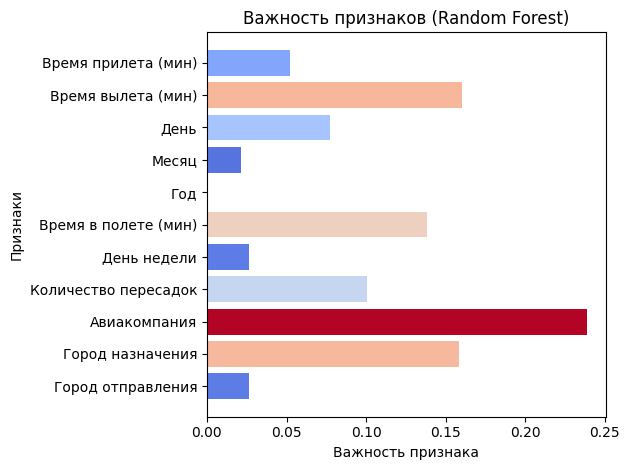

In [22]:
plt.barh(X.columns, rf.feature_importances_, color=plt.cm.coolwarm(rf.feature_importances_ / max(rf.feature_importances_)))
plt.xlabel("Важность признака")
plt.ylabel("Признаки")
plt.title("Важность признаков (Random Forest)")
plt.tight_layout()
plt.show()

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

from keras import Input
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train_dl, y_train_dl, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

print("DL Модель (Keras):")
loss, mae = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print("MAE:", mae)


Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0819 - mae: 0.2134 - val_loss: 0.0053 - val_mae: 0.0521
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0149 - mae: 0.0931 - val_loss: 0.0037 - val_mae: 0.0427
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081 - mae: 0.0682 - val_loss: 0.0027 - val_mae: 0.0330
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - mae: 0.0541 - val_loss: 0.0023 - val_mae: 0.0296
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043 - mae: 0.0454 - val_loss: 0.0022 - val_mae: 0.0283
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0040 - mae: 0.0403 - val_loss: 0.0021 - val_mae: 0.0279
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0361 - val_loss: 0.0020 - val_mae: 0.0274
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - mae: 0.0342 - val_loss: 0.0020 - val_mae: 0.0274
Epoch 9/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [35]:
def recommend_best_routes(df, departure_city, max_transfers=0, weekday=None):
    subset = df[df['Город отправления'] == departure_city]
    if weekday is not None:
        subset = subset[subset['День недели'] == weekday]
    subset = subset[subset['Количество пересадок'] <= max_transfers]
    best = subset.sort_values(by="Цена билета").head(5)
    return best[['Город отправления', 'Город назначения', 'Цена билета', 'День недели', 'Авиакомпания']]

print("Пример рекомендаций из города 2:")
recommend_best_routes(df, departure_city=2, weekday=5)

Пример рекомендаций из города 2:


,Город отправления,Город назначения,Цена билета,День недели,Авиакомпания
75,2,26,0.003414,5,26
81,2,26,0.003939,5,22
2460,2,26,0.004727,5,26
2466,2,26,0.005252,5,22
9,2,3,0.006040,5,26
